## TESTING MARGINALS

In [1]:
import autograd.numpy as anp
from autograd import grad
import numpy as np
from scipy import special, integrate
from scipy.stats import t as student_t
import matplotlib.pyplot as plt

import os
os.chdir('..')
os.getcwd()
from sazz.samplers.boomerang_sampler.BoomerangSampler import BoomerangSampler
from sazz.samplers.boomerang_sampler.utils import resample_pdmp_path


## Beta-Binomial
We look for a distribution where the marginals are available analytically. It is beneficial if the distribution is not Gaussian, as the reference can easily sample from a Gaussian. First, we look at the Beta-Binomial model. We are interested in determining the number of events $x$ in $n$ trials. The probability $p$ of an event is assigned a Beta prior, such that
$$
\pi(x, p) = \mathrm{Binom}(x \mid n, p)\mathrm{Beta}(p \mid \alpha, \beta) = \binom{n}{x}p^x(1-p)^{n-x}\frac{1}{\mathrm{B}(\alpha, \beta)}p^{\alpha-1}(1-p)^{\beta-1}
$$
Marginalizing over $p$ yields
$$
\pi(x) = \int_0^1\mathrm{Binom}(x \mid n, p)\mathrm{Beta}(p \mid \alpha, \beta)dp = \binom{n}{x}\frac{1}{\mathrm{B}(\alpha, \beta)} \int_0^1 p^{x+\alpha-1}(1-p)^{n-x+\beta-1} dp \\
=\binom{n}{x}\frac{\mathrm{B}(x+\alpha, n-x+\beta)}{\mathrm{B}(\alpha, \beta)}
$$
and the posterior for $p$ can be expressed as
$$
\pi(p\mid x) = \frac{\pi(x \mid p)\pi(p)}{\pi(x)} = \frac{\binom{n}{x}p^x(1-p)^{n-x}\frac{1}{\mathrm{B}(\alpha, \beta)}p^{\alpha-1}(1-p)^{\beta-1}}{\binom{n}{x}\frac{\mathrm{B}(x+\alpha, n-x+\beta)}{\mathrm{B}(\alpha, \beta)}} \\
= \frac{p^{x+\alpha-1}(1-p)^{n-x+\beta-1}}{\mathrm{B}(x+\alpha, n-x+\beta)} \\
= \mathrm{Beta}(a, b)
$$
where $a=x+\alpha$ and $b=n-x+\beta$. This posterior for $p$ lives in $(0, 1)$, and so we apply the change of variable
$$
\theta = \log\left(\frac{p}{1-p}\right) \qquad p=\frac{1}{1+e^{-\theta}} \qquad \frac{dp}{d\theta} = (1-\frac{1}{1+e^{-\theta}})\frac{1}{1+e^{-\theta}}
$$
such that
$$
\pi(\theta\mid x) = \pi(p(\theta \mid x))\frac{dp}{d\theta} = \frac{1}{\mathrm{B}(a, b)}\left(\frac{1}{1+e^{-\theta}}\right)^{a-1}\left(1-\frac{1}{1+e^{-\theta}}\right)^{b-1}\left(1-\frac{1}{1+e^{-\theta}}\right)\frac{1}{1+e^{-\theta}} \\
= \frac{1}{\mathrm{B}(a, b)}\left(\frac{1}{1+e^{-\theta}}\right)^{a}\left(1-\frac{1}{1+e^{-\theta}}\right)^{b}
$$
which is the target we must supply to the Boomerang sampler.
Immediately, we may find 
$$
\pi(\theta \mid x) \propto \exp(-E(\theta)) \\
E(\theta) = - \ln\pi(\theta \mid x) = -\left(-\ln\left(\frac{1}{\mathrm{B}(a, b)}\right) -a\ln(1+e^{-\theta}) +b\ln\left(\frac{e^{-\theta}}{1+e^{-\theta}}\right) \right) \\
= \ln\left(\mathrm{B}(a, b)\right) + a\ln(1+e^{-\theta}) + b\theta + b\ln(1+e^{-\theta})
$$
such that 
$$
\nabla E(\theta) = a\frac{-e^{-\theta}}{1+e^{-\theta}} + b + b\frac{-e^{-\theta}}{1+e^{-\theta}} = a\frac{-e^{-\theta}}{1+e^{-\theta}} + b\left(1+\frac{-e^{-\theta}}{1+e^{-\theta}}\right) = a\frac{-e^{-\theta}}{1+e^{-\theta}} + b\left(\frac{1}{1+e^{-\theta}}\right)
$$
Now, for $d$ independent experiments, one would obtain
$$
E(\boldsymbol{\theta}) =  \sum_{i=1}^d \ln\left(\mathrm{B}(a_i, b_i)\right) +  a_i\ln(1+e^{-\theta_i}) + b_i\theta_i + b_i\ln(1+e^{-\theta_i})
$$
and
$$
\nabla E(\theta)_i = a_i\frac{-e^{-\theta_i}}{1+e^{-\theta_i}} + b_i\left(\frac{1}{1+e^{-\theta_i}}\right)
$$

In [2]:
# ============================================================
# 1. Beta-Binomial on log-odds scale (multivariate, D independent)
# ============================================================
def nll_beta_binomial(a_post, b_post):
    a_post = anp.array(a_post, dtype=float)
    b_post = anp.array(b_post, dtype=float)

    def E(theta):
        return anp.sum(
            a_post * anp.log(1 + anp.exp(-theta))
            + b_post * theta
            + b_post * anp.log(1 + anp.exp(-theta))
        )
    return E

def marginal_pdf_beta_binomial(theta_j, a_j, b_j):
    sigma = 1.0 / (1.0 + np.exp(-theta_j))
    return sigma**a_j * (1 - sigma)**b_j / special.beta(a_j, b_j)

# --- Setup ---
# Example: 5 independent binomial experiments
D_bb = 5
np.random.seed(42)
a_prior = np.ones(D_bb) * 2.0  # Beta(2,2) prior
b_prior = np.ones(D_bb) * 2.0
n_obs = np.array([30, 50, 20, 40, 60])
x_obs = np.array([20, 25, 5, 30, 35])  # observed successes

a_posterior = a_prior + x_obs
b_posterior = b_prior + (n_obs - x_obs)

E_bb = nll_beta_binomial(a_posterior, b_posterior)
gradE_bb = grad(E_bb)

# --- Beta-Binomial: marginal of coordinate 0 ---
grid_bb = np.linspace(-4, 6, 500)
pdf_bb_0 = marginal_pdf_beta_binomial(grid_bb, a_posterior[0], b_posterior[0])


In [3]:
N=20000
sampler_bb = BoomerangSampler(E=E_bb, N=N, D=D_bb, grad_target=gradE_bb)
sampler_bb.preprocess(method="diagonal")
sampler_bb.sample_auto()

Boomerang time: 100%|█████████▉| 19999/20000 [01:33<00:00, 213.88iter/s, time=18458.996]

Time passed: 18458.996199309862


In [4]:
t_bb, samp_bb = resample_pdmp_path(
    sampler=sampler_bb, n_samples=1000000
)

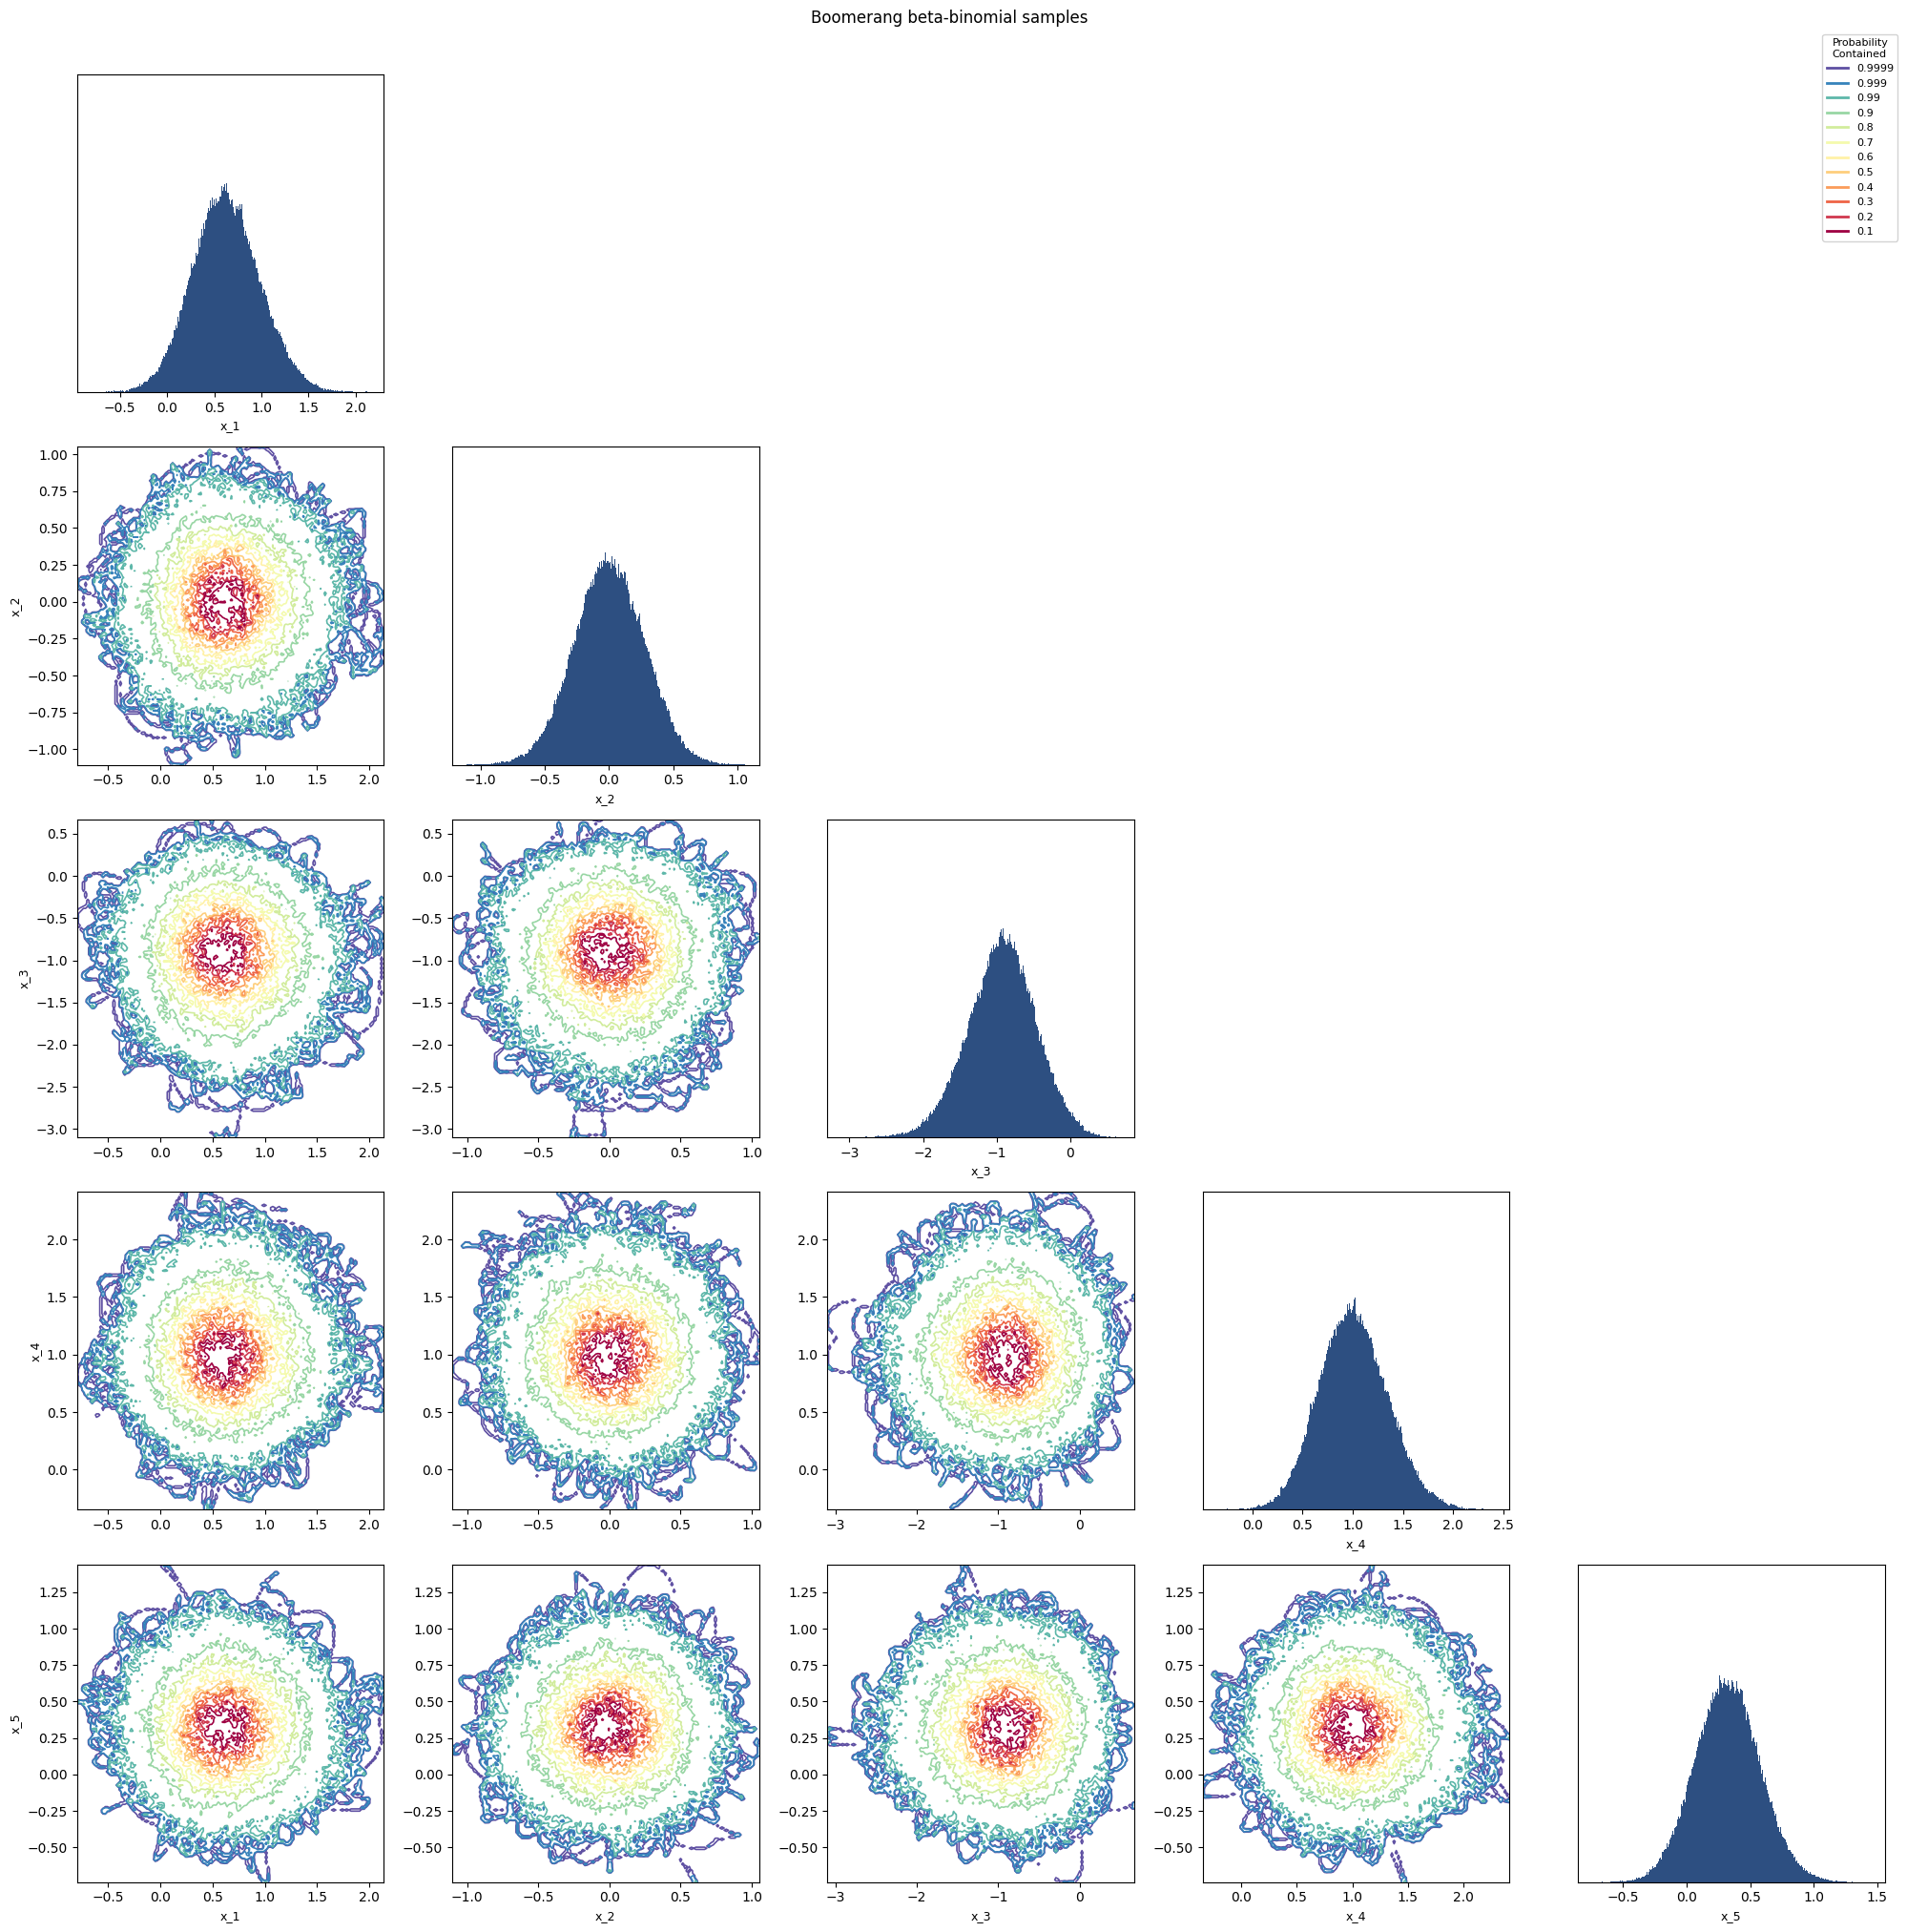

In [5]:
# ── Plug in your own samples here ─────────────────────────────────────────────
from Filippo_plotting.mcmc_plots import better_pairs
variable_names_bb = ['x_1', 'x_2', 'x_3', 'x_4', 'x_5']   # optional

fig, axes = better_pairs(
    samp_bb,
    resol=0.7,           # increase if contours are too jagged; decrease if over-smoothed
    labels=variable_names_bb,
    title='Boomerang beta-binomial samples',
)
plt.show()

## Neals Funnel

The d-dimensional model is of the form
$$
v \sim \mathcal{N}(0, \sigma^2) \\
x_i \mid v \sim \mathcal{N}(0, e^v) \qquad i=1, \dots, d-1
$$
such that
$$
\pi(v) = \frac{1}{\sqrt{2\pi\sigma^2}}\exp\left({-\frac{v^2}{2\sigma^2}}\right) \\
\pi(x_i) = \frac{1}{\sqrt{2\pi e^v}}\exp\left({-\frac{x_i^2}{2e^v}}\right) 
$$
and jointly
$$
\pi(v, x_1, \dots, x_{d-1}) = \frac{1}{\sqrt{2\pi\sigma^2}}\exp\left({-\frac{v^2}{2\sigma^2}}\right)\prod_{i=1}^{d-1}\frac{1}{\sqrt{2\pi e^v}}\exp\left({-\frac{x_i^2}{2e^v}}\right)
$$
which gives 
$$
E(v, \mathbf{x}) = - \ln \pi(v, \mathbf{x}) = -\left(-\ln\sqrt{2\pi\sigma^2} - \frac{v^2}{2\sigma^2} -(d-1)\ln\sqrt{2\pi} - \frac{d-1}{2}v -\sum_{i=1}^{d-1}\frac{x_i^2}{2e^v} \right) \\
= \ln\sqrt{2\pi\sigma^2} +(d-1)\ln\sqrt{2\pi} + \frac{v^2}{2\sigma^2} + \frac{d-1}{2}v +\sum_{i=1}^{d-1}\frac{x_i^2}{2e^v}
$$
and 
$$
\nabla_v E(v, \mathbf{x}) = \frac{v}{\sigma^2} + \frac{d-1}{2} - \sum_{i=1}^{d-1}\frac{x_i^2}{2e^v} = \frac{v}{\sigma^2} + \frac{d-1}{2} - \frac{e^{-v}}{2}\sum_{i=1}^{d-1}x_i^2 \\
\nabla_x E(v, \mathbf{x}) = \frac{x_i}{e^v} = x_ie^{-v}
$$
The marginal of $v$ is simply a Gaussian, as it is independent of the $x_i$'s, and the marginal of the $x_i$'s is given by
$$
\pi(x_i) = \int_{-\infty}^{\infty}\frac{1}{\sqrt{2\pi\sigma^2}}\exp\left({-\frac{v^2}{2\sigma^2}}\right)\frac{1}{\sqrt{2\pi e^v}}\exp\left({-\frac{x_i^2}{2e^v}}\right)dv
$$
which is not tractable, but can be approximated by numerical integration.

In [6]:
# ============================================================
# 2. Neal's Funnel
# ============================================================
def nll_neals_funnel(sigma_v=3.0, D=10):
    def E(theta):
        v = theta[0]
        x = theta[1:]
        nll_v = 0.5 * v**2 / sigma_v**2 + 0.5 * (len(theta) - 1) * v
        nll_x = anp.sum(0.5 * x**2 * anp.exp(-v)) 
        return nll_v + nll_x

    return E


def marginal_pdf_funnel_x(x_val, sigma_v=3.0, D_minus_1=9):
    def integrand(v):
        log_p_v = -0.5 * v**2 / sigma_v**2 - 0.5 * np.log(2 * np.pi * sigma_v**2)
        log_p_x_given_v = -0.5 * x_val**2 * np.exp(-v) - 0.5 * v - 0.5 * np.log(2 * np.pi)
        return np.exp(log_p_v + log_p_x_given_v)

    result, _ = integrate.quad(integrand, -10 * sigma_v, 10 * sigma_v)
    return result


def marginal_pdf_funnel_v(v_val, sigma_v=3.0):
    """Marginal of v is just N(0, sigma_v^2)."""
    return np.exp(-0.5 * v_val**2 / sigma_v**2) / np.sqrt(2 * np.pi * sigma_v**2)

# --- Setup ---
D_funnel = 4
sigma_v = 3.0
E_funnel = nll_neals_funnel(sigma_v=sigma_v, D=D_funnel)
gradE_funnel = grad(E_funnel)

# --- Funnel: marginal of x_1 ---
grid_funnel_x = np.linspace(-30, 30, 500)
pdf_funnel_x = np.array([marginal_pdf_funnel_x(x, sigma_v=sigma_v) for x in grid_funnel_x])

grid_funnel_v = np.linspace(-12, 12, 500)
pdf_funnel_v = marginal_pdf_funnel_v(grid_funnel_v, sigma_v=sigma_v)

In [7]:
N=20000
sampler_funnel = BoomerangSampler(E=E_funnel, N=N, D=D_funnel, grad_target=gradE_funnel)
import numpy as np

x_ref = np.zeros(D_funnel) 
# Precision = 1/variance for each coordinate
Sigma_ref = np.diag(np.ones(D_funnel))
Sigma_ref[0, 0] = 1.0 / sigma_v**2
# x coordinates keep 1.0 on the diagonal

Sigma_ref_inv = np.linalg.inv(Sigma_ref)

In [8]:
sampler_funnel.preprocess(method="manual", x_ref=x_ref, Sigma_inv=Sigma_ref_inv)
sampler_funnel.sample_auto()

Boomerang time: 100%|█████████▉| 19999/20000 [03:35<00:00, 93.01iter/s, time=6835.956] 

Time passed: 6835.955585719185


In [9]:
t_funnel, samp_funnel = resample_pdmp_path(
    sampler=sampler_funnel, n_samples=1000000
)

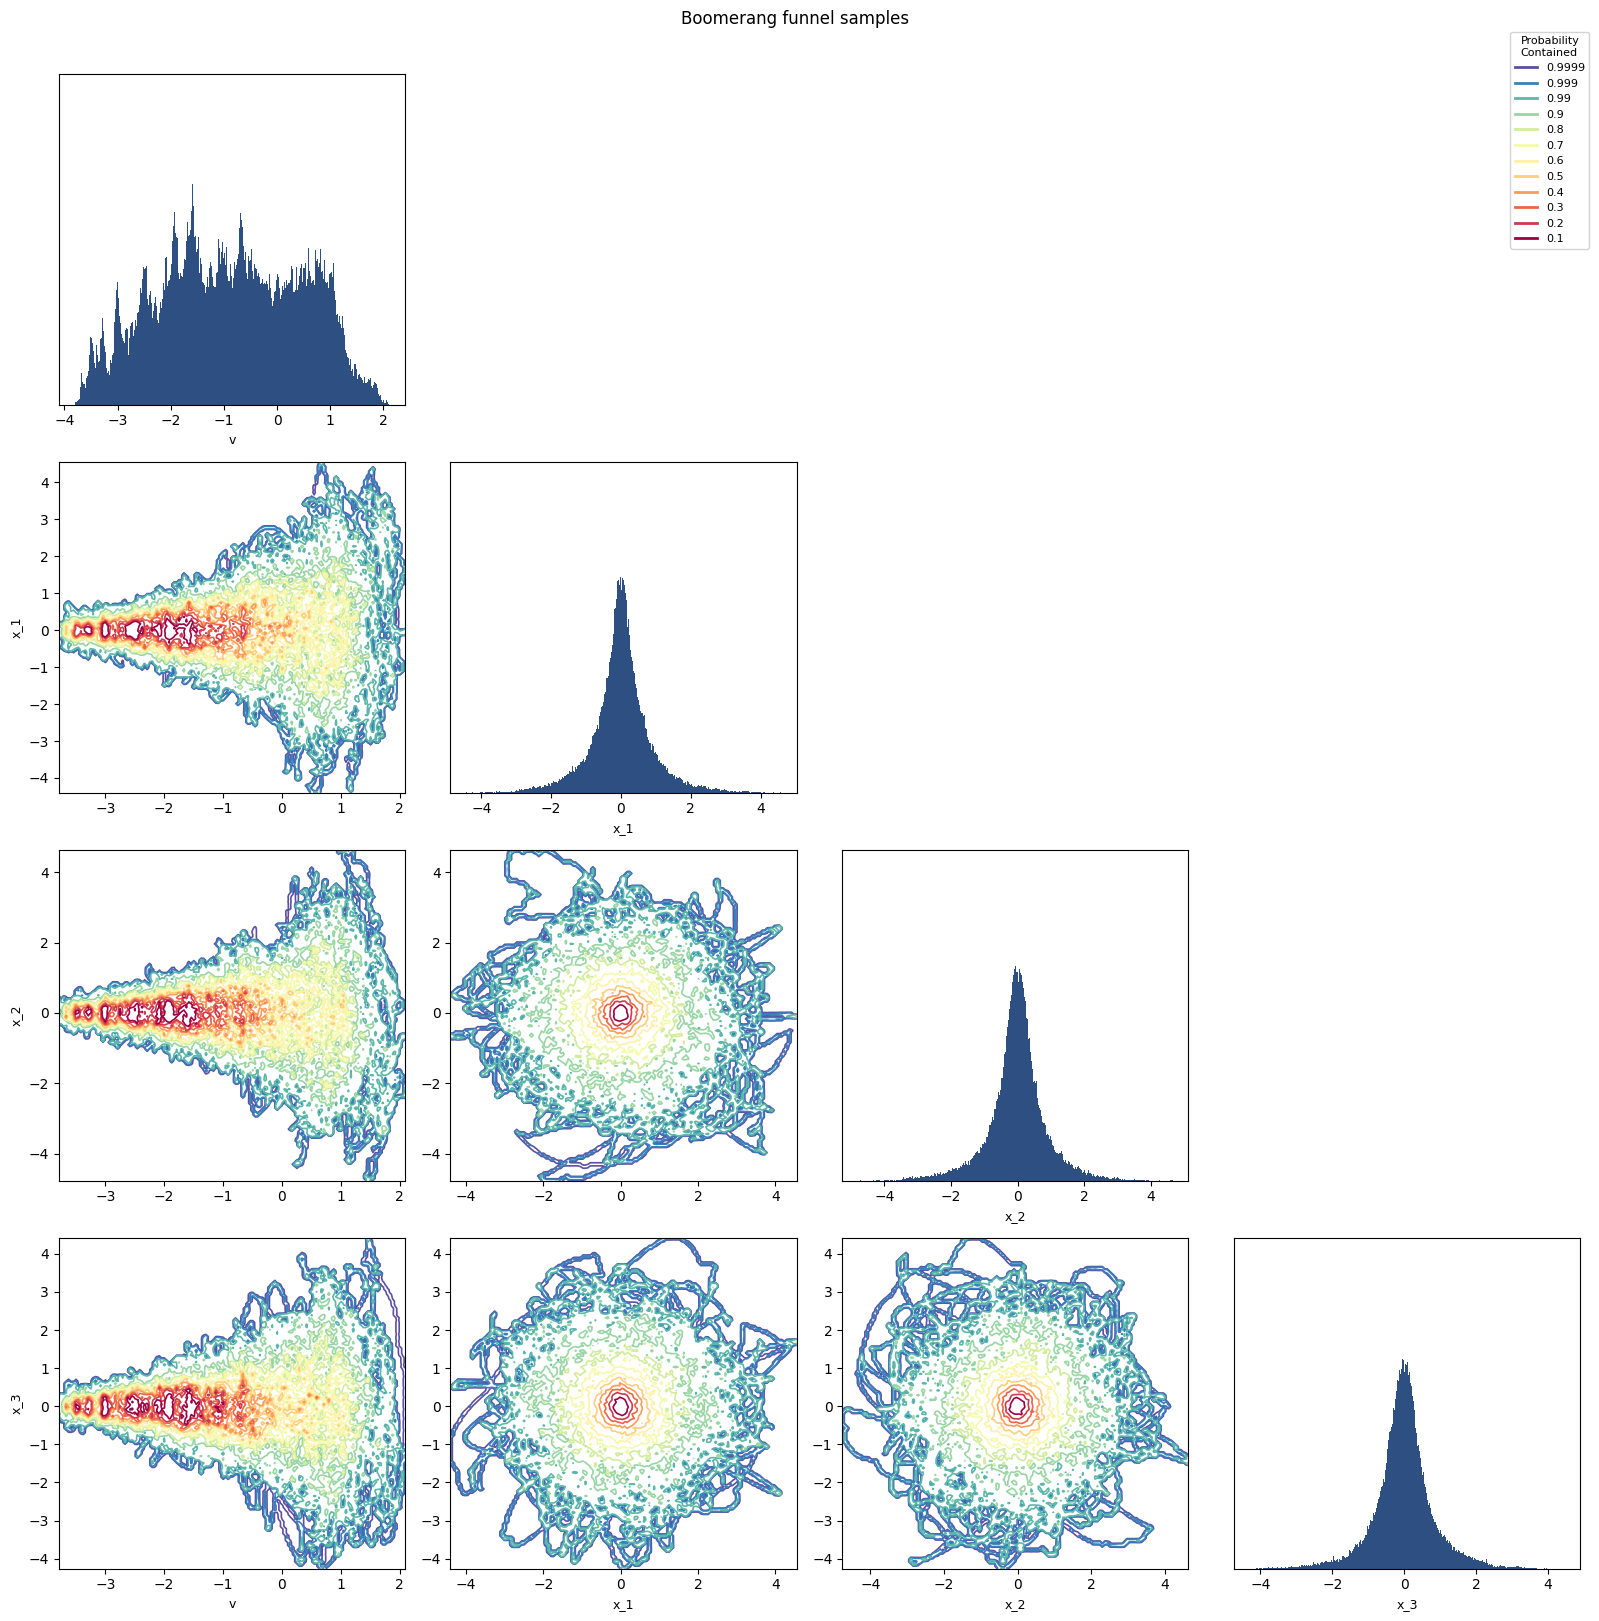

In [10]:
# ── Plug in your own samples here ─────────────────────────────────────────────
variable_names_funnel = ['v', 'x_1', 'x_2', 'x_3', 'x_4']   # optional

fig, axes = better_pairs(
    samp_funnel,
    resol=0.7,           # increase if contours are too jagged; decrease if over-smoothed
    labels=variable_names_funnel,
    title='Boomerang funnel samples',
)
plt.show()

## ROSENBROCK BANANA

The Rosembrock banana is defined stragiht from its energy function
$$
E(x_1, x_2) = \frac{1}{2}x_1^2 + \frac{1}{2}(x_2 - ax_1^2)^2
$$
which yields
$$
\nabla_{x_1}E(x_1, x_2) = x_1 - 2ax_1 (x_2-ax_1^2) \\
\nabla_{x_2}E(x_1, x_2) = x_2 - ax_1^2
$$
Notice how $x_2 \mid x_1$ is Gaussian, so the marginal for $x_1$ is available as
$$
\pi(x_1) \propto -\exp(-\frac{1}{2}x_1^2)
$$
and the marginal of $x_2$ requires numerical integration of the integral
$$
\pi(x_2) \propto \int_{-\infty}^{\infty}\exp(-\frac{1}{2}x_1^2 -  \frac{1}{2}(x_2 - ax_1^2)^2) dx_1
$$

In [11]:
# ============================================================
# 3. Banana with Gaussian prior
# ============================================================
def nll_banana(a=1.0):
    def E(beta):
        banana = 0.5 * (beta[0]**2 + (beta[1] - a * beta[0]**2)**2)
        return banana

    return E


def marginal_pdfs_banana(a=1.0, grid_0=None, grid_1=None):
    def unnorm_joint(b0, b1):
        E_val = 0.5 * (b0**2 + (b1 - a * b0**2)**2)
        return np.exp(-E_val)

    Z, _ = integrate.dblquad(unnorm_joint, -8, 8, -8, 8)

    marginal_0 = np.zeros_like(grid_0)
    for i, b0 in enumerate(grid_0):
        val, _ = integrate.quad(lambda b1: unnorm_joint(b0, b1), -8, 8)
        marginal_0[i] = val / Z

    marginal_1 = np.zeros_like(grid_1)
    for i, b1 in enumerate(grid_1):
        val, _ = integrate.quad(lambda b0: unnorm_joint(b0, b1), -8, 8)
        marginal_1[i] = val / Z

    return marginal_0, marginal_1


# --- Setup ---
a_banana = 1.0
E_banana = nll_banana(a=a_banana)
gradE_banana = grad(E_banana)

# --- Banana with prior: both marginals ---
grid_b0 = np.linspace(-4, 4, 300)
grid_b1 = np.linspace(-2, 6, 300)
marg_0, marg_1 = marginal_pdfs_banana(a=a_banana,
                                        grid_0=grid_b0, grid_1=grid_b1)

In [12]:
N=20000
sampler_banana = BoomerangSampler(E=E_banana, N=N, D=2, grad_target=gradE_banana)
sampler_banana.preprocess(method="diagonal")
sampler_banana.sample_auto()

Boomerang time: 100%|█████████▉| 19999/20000 [01:42<00:00, 195.32iter/s, time=11492.522]

Time passed: 11492.52186495963


In [13]:
t_banana, samp_banana = resample_pdmp_path(
    sampler=sampler_banana, n_samples=1000000
)

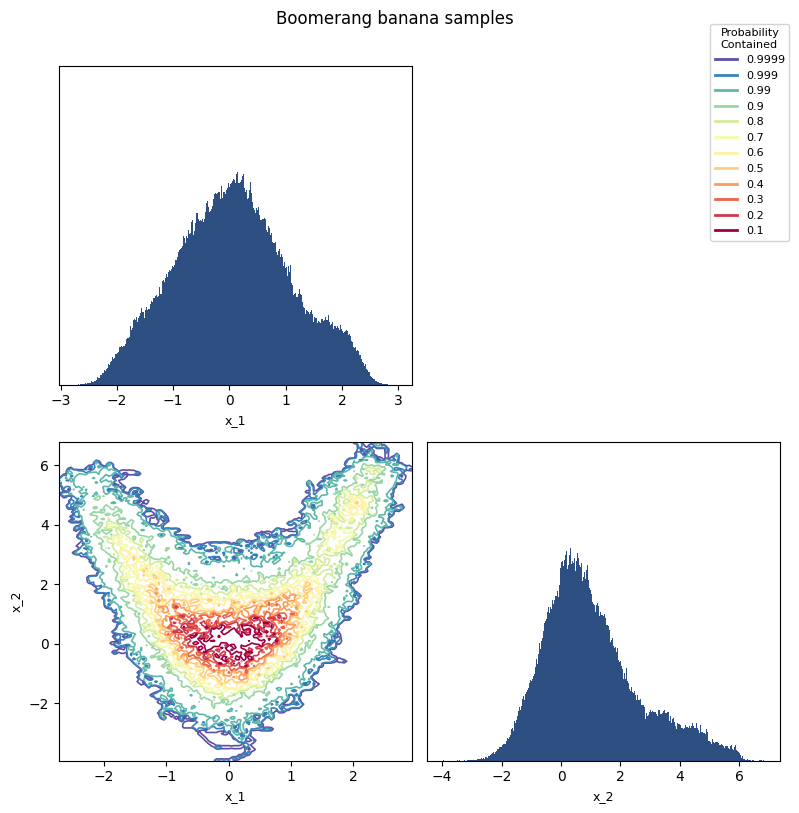

In [14]:
# ── Plug in your own samples here ─────────────────────────────────────────────
variable_names_banana = ['x_1', 'x_2']   # optional

fig, axes = better_pairs(
    samp_banana,
    resol=0.7,           # increase if contours are too jagged; decrease if over-smoothed
    labels=variable_names_banana,
    title='Boomerang banana samples',
)
plt.show()